**Group Members**:  
- Joanne Ching Yin Xuan (A23CS0227)  
- Lim Yu Han (A23CS0241)  
- Tan Zhi Ming (A23CS0189)

# Rainfall Data Analysis Assignment (100 Marks, Due 6th July 2025)

You are provided with a rainfall dataset recording monthly measurements from various weather stations across different regions. The dataset includes rainfall (mm), number of rainy days, maximum and minimum temperatures, and whether the station is in an urban or rural area.

Dataset columns:

- `Region`: Name of the region (e.g., North, South, East, West)
- `Year`: Year of measurement
- `Month`: Month (e.g., Jan, Feb, ..., Dec)
- `Station`: Weather station name/ID (e.g., StationA, StationB)
- `Rainfall_mm`: Rainfall amount in millimeters
- `RainyDays`: Number of days in the month with rain
- `MaxTemp_C`: Maximum temperature recorded in that month (°C)
- `MinTemp_C`: Minimum temperature recorded in that month (°C)
- `UrbanRural`: "Urban" or "Rural"

## Part 1: Data Exploration ( 15 Marks)

1. Load the data into a pandas DataFrame. (2 Marks)
2. Display the first 5 rows of the DataFrame. (2 Marks)
3. Check for and handle any missing values. (6 Marks)
4. Provide summary statistics for all numeric columns. (5 Marks)

In [5]:
#Write your code here
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('Rainfall.csv' , header = None)
df = df[0].str.split(",", expand=True) # split 1st column by comma bcs all stick tgt

# rename the columns
df.columns = ["Region", "Year", "Month", "Station", "Rainfall_mm", "RainyDays", "MaxTemp_C", "MinTemp_C", "UrbanRural"]

df.columns = df.columns.str.strip()

# After we rename , we need to drop the first row manually
df = df.drop(index=0).reset_index(drop=True)

# Change object to numeric type
df = df.astype({
    "Year": int,
    "Rainfall_mm": float,
    "RainyDays": int,
    "MaxTemp_C": float,
    "MinTemp_C": float
})

# 2. Display the first 5 rows of the DataFrame
print("First 5 rows of dataset:\n")
print(df.head())
print()

# 3. Check for and handle any missing values
from numpy import nan as NA
print("Overview of missing value")
print(df.isnull())
print()
print("Total missing value")
print(df.isnull().sum())
print()

# 4. Provide summary statistics for all numeric columns
print("\nSummary statistics for numeric columns:")
print(df.describe())

First 5 rows of dataset:

  Region  Year Month   Station  Rainfall_mm  RainyDays  MaxTemp_C  MinTemp_C  \
0  North  2023   Jan  StationA         56.2          9       12.1        2.5   
1  North  2023   Feb  StationA         72.1         12       14.7        3.0   
2  North  2023   Jan  StationB         60.5         10       11.2        1.8   
3  South  2023   Jan  StationC         81.0         13       19.6        7.2   
4  South  2023   Feb  StationC         63.4         11       20.1        7.7   

  UrbanRural  
0      Urban  
1      Urban  
2      Rural  
3      Urban  
4      Urban  

Overview of missing value
   Region   Year  Month  Station  Rainfall_mm  RainyDays  MaxTemp_C  \
0   False  False  False    False        False      False      False   
1   False  False  False    False        False      False      False   
2   False  False  False    False        False      False      False   
3   False  False  False    False        False      False      False   
4   False  False  Fal

## Part 2: Grouping and Aggregation (30 Marks)

1. For each **Station**, compute: (6 Marks)
    - Total rainfall 
    - Average number of rainy days 
    - Average maximum temperature 
    - Average minimum temperature



In [8]:
# Write your code here
# Group by Station and aggregate
station_stats = df.groupby("Station").agg({
    "Rainfall_mm": "sum",
    "RainyDays": "mean",
    "MaxTemp_C": "mean",
    "MinTemp_C": "mean"
})

# Show results
print("\nTotal Rainfall, Avg no Rainy Days, Avg Max and Min Temp by Station:")
print()
station_stats


Total Rainfall, Avg no Rainy Days, Avg Max and Min Temp by Station:



,Rainfall_mm,RainyDays,MaxTemp_C,MinTemp_C
Station,,,,
StationA,128.3,10.5,13.40,2.75
StationB,122.0,10.5,13.10,2.50
StationC,144.4,12.0,19.85,7.45
StationD,105.3,9.0,16.65,5.90
StationE,161.6,12.5,17.50,5.10


2. For each **Region & UrbanRural** combination, calculate: (6 Marks)
    - Average rainfall
    - Average maximum temperature
    - Average number of rainy days


In [11]:
#Write your code here
regionAndUrbanRural_stats = df.groupby(["Region","UrbanRural"]).agg({
    "Rainfall_mm": "mean",
    "MaxTemp_C": "mean",
    "RainyDays": "mean",
}).reset_index()

# Show results
print("\nAvg Rainfall,Avg MaxTemp_C and Avg no of rainy days:")
print()
regionAndUrbanRural_stats



Avg Rainfall,Avg MaxTemp_C and Avg no of rainy days:



,Region,UrbanRural,Rainfall_mm,MaxTemp_C,RainyDays
0,East,Rural,52.65,16.65,9.0
1,North,Rural,61.00,13.10,10.5
2,North,Urban,64.15,13.40,10.5
3,South,Urban,72.20,19.85,12.0
4,West,Urban,80.80,17.50,12.5


3. For each **Month** and **Region**, calculate: (6 Marks)
    - Total rainfall
    - Mean rainfall
    - Minimum and maximum rainfall


In [14]:
#Write your code here
# Group by Month and Region
month_region_stats = df.groupby(["Month", "Region"])["Rainfall_mm"].agg(
    Total_Rainfall="sum",
    Mean_Rainfall="mean",
    Min_Rainfall="min",
    Max_Rainfall="max"
).reset_index()

# Display the result
print("Rainfall stats by Month and Region:\n")
month_region_stats


Rainfall stats by Month and Region:



,Month,Region,Total_Rainfall,Mean_Rainfall,Min_Rainfall,Max_Rainfall
0,Feb,East,59.6,59.60,59.6,59.6
1,Feb,North,72.1,72.10,72.1,72.1
2,Feb,South,63.4,63.40,63.4,63.4
3,Feb,West,84.2,84.20,84.2,84.2
4,Jan,East,45.7,45.70,45.7,45.7
5,Jan,North,116.7,58.35,56.2,60.5
6,Jan,South,81.0,81.00,81.0,81.0
7,Jan,West,77.4,77.40,77.4,77.4
8,Mar,North,61.5,61.50,61.5,61.5


4. Find the **Region and Month** with the highest recorded rainfall in the dataset. (4 Marks)


In [17]:
#Write your code here
# Find the row with the highest rainfall

# Sort the DataFrame by Rainfall_mm in descending order
sorted_df = df.sort_values(by="Rainfall_mm", ascending=False)

# Take the first row (highest rainfall)
highest_rainfall_row = sorted_df.iloc[0][["Region", "Month", "Rainfall_mm"]]

print("Region and Month with the highest recorded rainfall:\n")
print(highest_rainfall_row)



Region and Month with the highest recorded rainfall:

Region         West
Month           Feb
Rainfall_mm    84.2
Name: 8, dtype: object


5. For each **Year** and **UrbanRural** group, calculate: (4 Marks)
    - Average rainfall
    - Minimum rainfall
    - Maximum rainfall



In [20]:
#Write your code here
year_urbanRural_stats = df.groupby(["Year","UrbanRural"])["Rainfall_mm"].agg(
    Average_Rainfall = "mean",
    Minimum_Rainfall = "min",
    Maximum_Rainfall = "max"
).reset_index()


print("Average, Min, and Max Rainfall by Year and Urban/Rural:\n")
year_urbanRural_stats


Average, Min, and Max Rainfall by Year and Urban/Rural:



,Year,UrbanRural,Average_Rainfall,Minimum_Rainfall,Maximum_Rainfall
0,2023,Rural,56.825000,45.7,61.5
1,2023,Urban,72.383333,56.2,84.2


6. For each **Region**, calculate the average temperature range per month (i.e., average of MaxTemp_C - MinTemp_C). (4 Marks)

In [22]:
# Write your code here
# New column for temperature range
df["Temp_Range"] = df["MaxTemp_C"] - df["MinTemp_C"]

avg_temp_range = df.groupby(["Region", "Month"])["Temp_Range"].mean().reset_index()

print("Average temperature range per month for each region:\n")
avg_temp_range



Average temperature range per month for each region:



,Region,Month,Temp_Range
0,East,Feb,11.7
1,East,Jan,9.8
2,North,Feb,11.7
3,North,Jan,9.5
4,North,Mar,11.8
5,South,Feb,12.4
6,South,Jan,12.4
7,West,Feb,12.9
8,West,Jan,11.9


## Part 3: Data Visualization (matplotlib) (40 Marks)

1. **Bar Chart:**  (8 Marks)
   - Plot total rainfall by region, colored by Urban/Rural.
   - Add value labels, gridlines, axis labels, title, and adjust bar width for clarity.



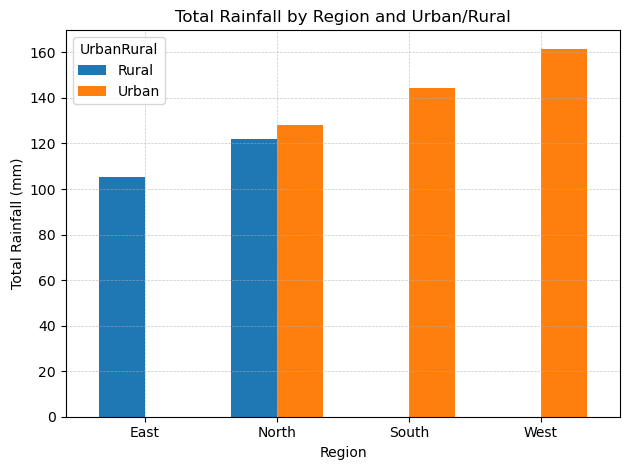

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

# Group total rainfall by Region and UrbanRural
rainfall_by_region = df.groupby(["Region", "UrbanRural"])["Rainfall_mm"].sum().unstack()

# Create bar chart
ax = rainfall_by_region.plot.bar(width=0.7)  # adjust bar width for clarity

# Add gridlines
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Add axis labels and title
ax.set_xlabel("Region")
ax.set_ylabel("Total Rainfall (mm)")
ax.set_title("Total Rainfall by Region and Urban/Rural")
plt.xticks(rotation=0)
# Prevent label overlapping
plt.tight_layout()

# Save the figure as png
plt.savefig("barchart_total_rainfall_by_region_urban_rural.png")

# Display the plot
plt.show()

2. **Grouped Bar Chart:**  (6 Marks)
   - Show average monthly rainfall for each station.
   - Use different colors for each station, include a legend, rotate x-tick labels, and increase figure size for readability.



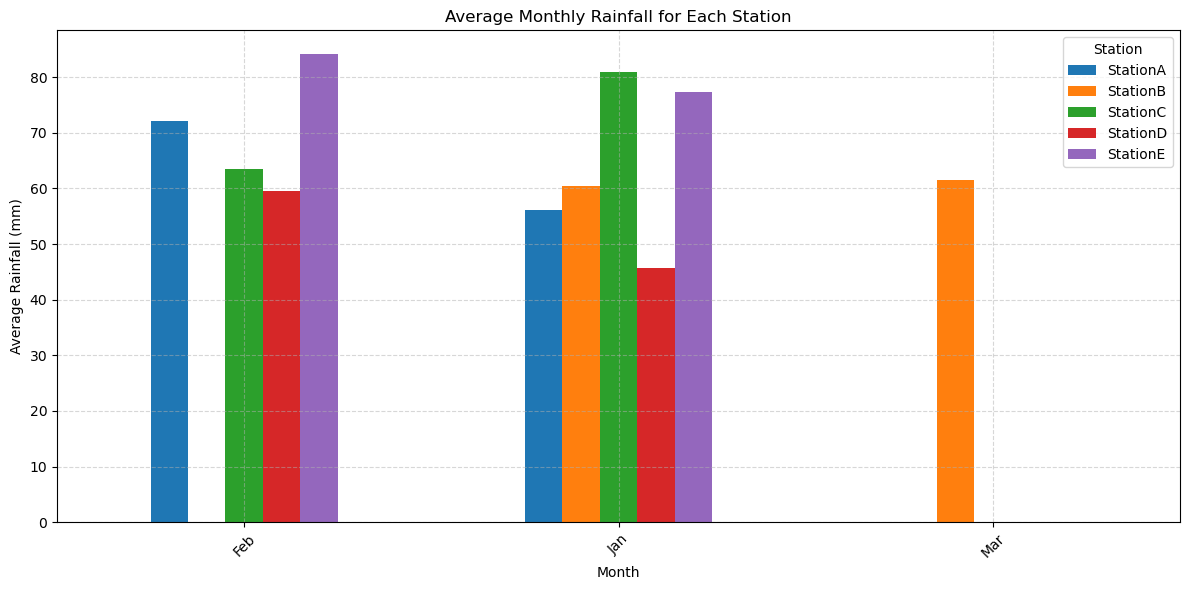

In [39]:
#Write your code here

# Group monthly rainfall for each station.
avg_rainfall = df.groupby(["Month", "Station"])["Rainfall_mm"].mean().unstack()

# 3. Plot grouped bar chart
ax = avg_rainfall.plot.bar(figsize=(12,6))  

# 4. Add labels
ax.set_xlabel("Month")
ax.set_ylabel("Average Rainfall (mm)")
ax.set_title("Average Monthly Rainfall for Each Station")

# 5. Add legend
ax.legend(title="Station")

# 6. Rotate x-axis labels
plt.xticks(rotation=45)

# 7. Output
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("barchart_mean_rainfall_per_station.png")

plt.show()


3. **Line Plot:**  (6 Marks)
   - Show the trend of rainfall over months for at least two selected stations.
   - Use markers, dashed lines, highlight the month with maximum rainfall, and format the x-axis for months.



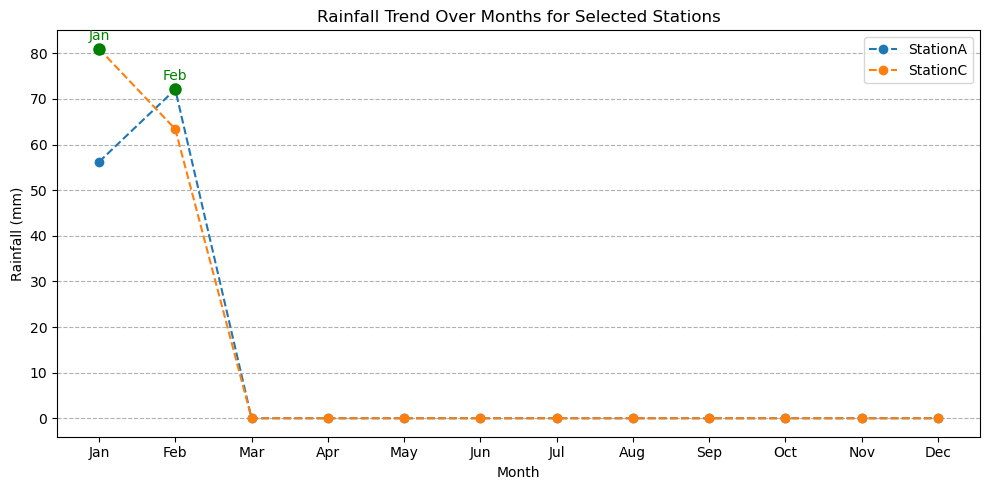

In [42]:
stations_selected = ['StationA', 'StationC']  
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_trend = df[df['Station'].isin(stations_selected)].groupby(['Station', 'Month'])['Rainfall_mm'].mean().unstack().reindex(columns=month_order, fill_value=0)

plt.figure(figsize=(10, 5))
for station in stations_selected:
    plt.plot(monthly_trend.columns, monthly_trend.loc[station], marker='o', linestyle='--', label=station)

for station in stations_selected:
    max_month = monthly_trend.loc[station].idxmax()
    max_value = monthly_trend.loc[station].max()
    
    plt.plot(max_month, max_value, marker='o', color='green', markersize=8)
    
    plt.text(max_month, max_value + 2, max_month, color='green', ha='center')
plt.legend()
plt.title('Rainfall Trend Over Months for Selected Stations')
plt.xlabel('Month')
plt.ylabel('Rainfall (mm)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig("lineplot_monthly_rainfall_trend_by_stations.png")
plt.show()


4. **Boxplot:**  (6 Marks)
   - Display rainfall distributions by region and by Urban/Rural.
   - Use custom box colors, highlight outliers, and set y-axis limits.



<Figure size 1000x600 with 0 Axes>

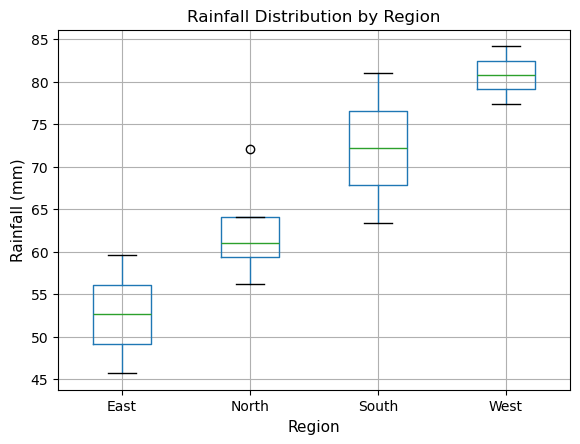

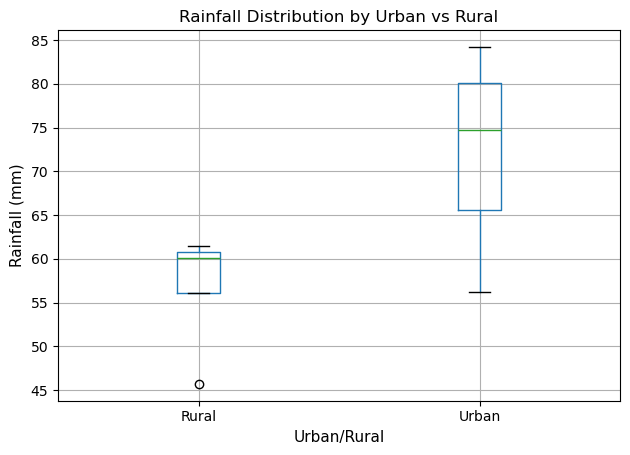

In [45]:
#Write your code here
plt.figure(figsize=(10, 6))
df.boxplot(column="Rainfall_mm", by="Region")
plt.title("Rainfall Distribution by Region", fontsize=12)
plt.suptitle("")
plt.xlabel("Region", fontsize=11)
plt.ylabel("Rainfall (mm)", fontsize=11)
plt.savefig("boxplot_rainfall_by_region.png")

df.boxplot(column="Rainfall_mm", by="UrbanRural")
plt.title("Rainfall Distribution by Urban vs Rural", fontsize=12)
plt.suptitle("")
plt.xlabel("Urban/Rural", fontsize=11)
plt.ylabel("Rainfall (mm)", fontsize=11)
plt.savefig("boxplot_rainfall_by_urbanrural.png")

plt.grid(True)
plt.tight_layout()
plt.show()


5. **Scatter Plot:**  (6 Marks)
   - Visualize the relationship between rainfall and maximum temperature, colored by region.
   - Add axis labels, legend, gridlines, and an appropriate title.



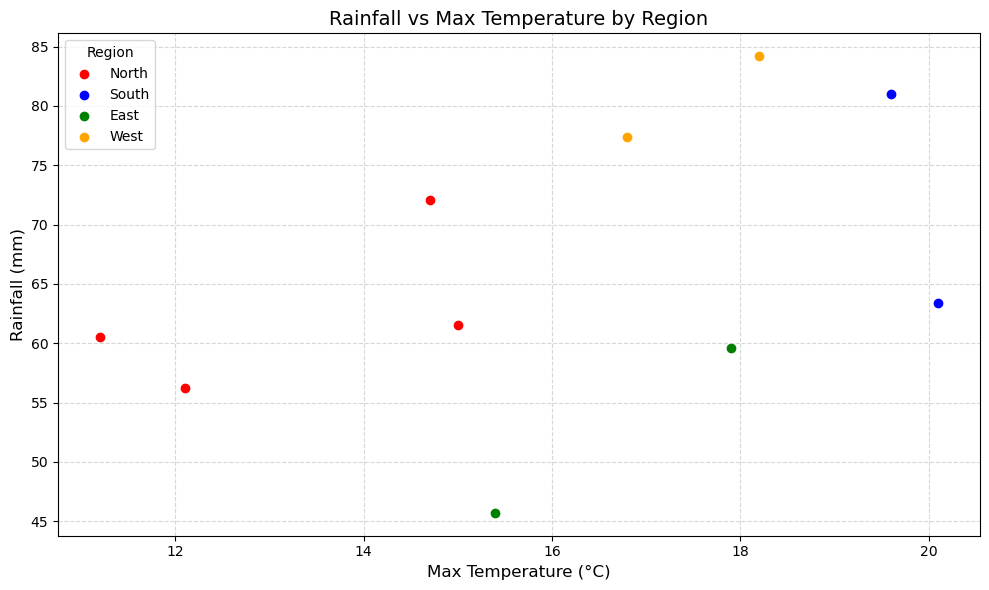

In [64]:
#Write your code here
plt.figure(figsize=(10, 6))

# region names 
region_north = df[df["Region"] == "North"]
region_south = df[df["Region"] == "South"]
region_east = df[df["Region"] == "East"]
region_west = df[df["Region"] == "West"]

# Scatter for each region with different colors
plt.scatter(region_north["MaxTemp_C"], region_north["Rainfall_mm"], color="red", label="North")
plt.scatter(region_south["MaxTemp_C"], region_south["Rainfall_mm"], color="blue", label="South")
plt.scatter(region_east["MaxTemp_C"], region_east["Rainfall_mm"], color="green", label="East")
plt.scatter(region_west["MaxTemp_C"], region_west["Rainfall_mm"], color="orange", label="West")

# formatting
plt.title("Rainfall vs Max Temperature by Region", fontsize=14)
plt.xlabel("Max Temperature (°C)", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.legend(title="Region")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("scatter_rainfall_vs_maxtemp_by_region.png")
plt.show()


6. **Heatmap:**  
   - Create a heatmap showing mean monthly rainfall for each region (Month on x-axis, Region on y-axis).
   - Add color bar, axis labels, and title.



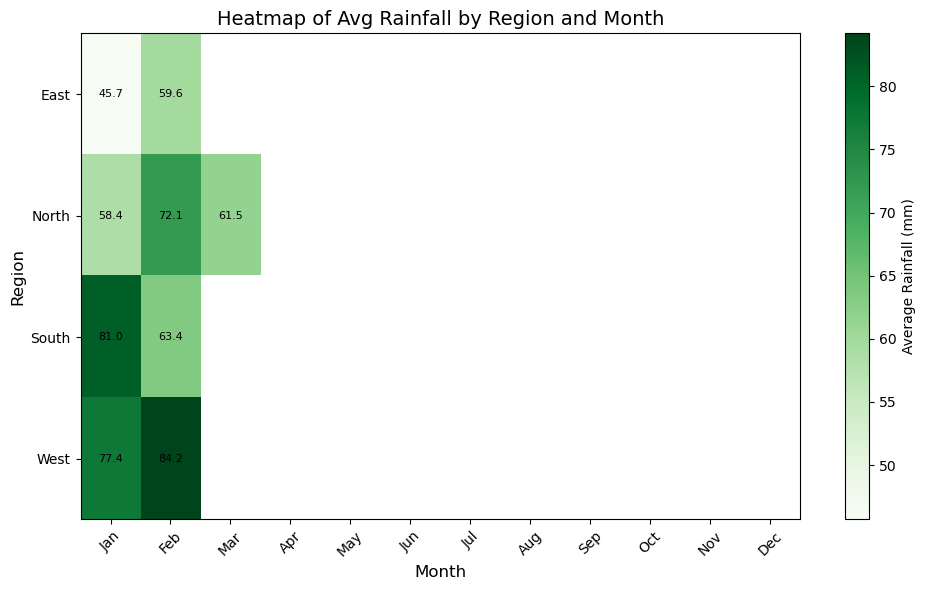

In [53]:
# Write your code here
# Create pivot table of average rainfall
pivot_table = df.pivot_table(values='Rainfall_mm', index='Region', columns='Month', aggfunc='mean')

# Reorder columns to follow month order
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pivot_table = pivot_table.reindex(columns=month_order)

# Plot heatmap
plt.figure(figsize=(10, 6))
plt.imshow(pivot_table, cmap='Greens', aspect='auto')

# Add color bar
plt.colorbar(label='Average Rainfall (mm)')

# Add axis labels and title
plt.title('Heatmap of Avg Rainfall by Region and Month', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Region', fontsize=12)
plt.xticks(ticks=range(len(pivot_table.columns)), labels=pivot_table.columns, rotation=45)
plt.yticks(ticks=range(len(pivot_table.index)), labels=pivot_table.index)

# Show value inside each heatmap block
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        value = pivot_table.iloc[i, j]
        if not pd.isna(value):
            plt.text(j, i, f"{value:.1f}", ha='center', va='center', color='black', fontsize=8)

# Output
plt.tight_layout()
plt.savefig("heatmap_mean_rainfall_by_region.png")
plt.show()


7. **Formatting (for all plots):** (8 Marks)
   - Use descriptive titles, axis labels, and legends.
   - Increase font size for readability.
   - Save each figure as an image file (`.png`).
   - Use `plt.tight_layout()` for proper spacing.

## Part 4: Bonus Tasks (15 Marks)

1. Annotate at least one plot with the value and label of the highest/lowest point. (5 Marks)


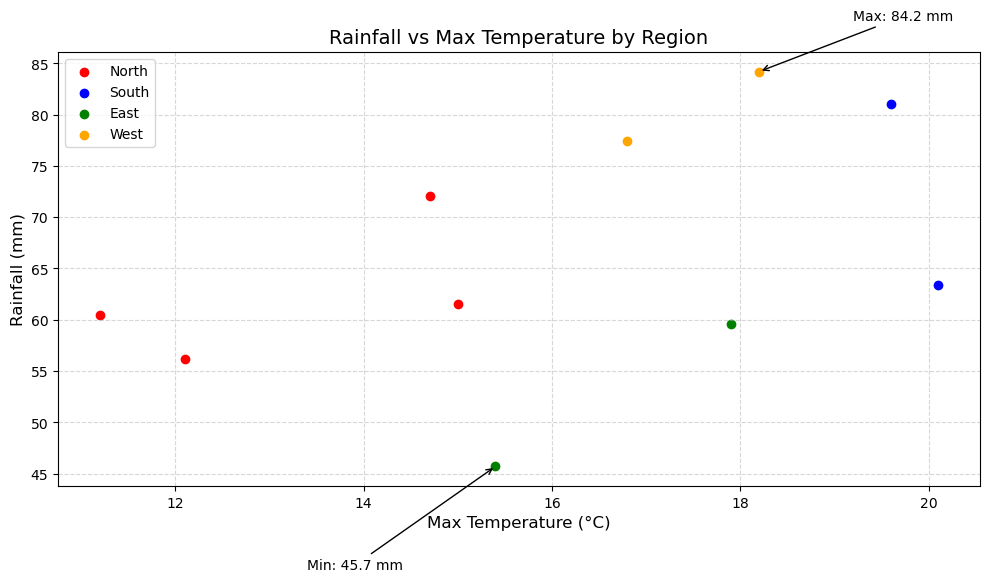

In [57]:
#Write your code here
plt.figure(figsize=(10, 6))

# Filter by region
region_north = df[df["Region"] == "North"]
region_south = df[df["Region"] == "South"]
region_east = df[df["Region"] == "East"]
region_west = df[df["Region"] == "West"]

# Scatter plots
plt.scatter(region_north["MaxTemp_C"], region_north["Rainfall_mm"], color="red", label="North")
plt.scatter(region_south["MaxTemp_C"], region_south["Rainfall_mm"], color="blue", label="South")
plt.scatter(region_east["MaxTemp_C"], region_east["Rainfall_mm"], color="green", label="East")
plt.scatter(region_west["MaxTemp_C"], region_west["Rainfall_mm"], color="orange", label="West")

# Find max and min rainfall points
max_rainfall = df.loc[df["Rainfall_mm"].idxmax()]
min_rainfall = df.loc[df["Rainfall_mm"].idxmin()]

# Annotate highest point
plt.annotate(f"Max: {max_rainfall['Rainfall_mm']} mm",
             xy=(max_rainfall['MaxTemp_C'], max_rainfall['Rainfall_mm']),
             xytext=(max_rainfall['MaxTemp_C'] + 1, max_rainfall['Rainfall_mm'] + 5),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Annotate lowest point
plt.annotate(f"Min: {min_rainfall['Rainfall_mm']} mm",
             xy=(min_rainfall['MaxTemp_C'], min_rainfall['Rainfall_mm']),
             xytext=(min_rainfall['MaxTemp_C'] - 2, min_rainfall['Rainfall_mm'] - 10),
             arrowprops=dict(facecolor='black', arrowstyle='->'),
             fontsize=10)

# Add labels and grid
plt.title("Rainfall vs Max Temperature by Region", fontsize=14)
plt.xlabel("Max Temperature (°C)", fontsize=12)
plt.ylabel("Rainfall (mm)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("updated_scatter_rainfall_vs_maxtemp_by_region.png")
plt.show()



2. Create a **facet/grid plot** comparing rainfall trends by region and Urban/Rural status. (5 Marks)


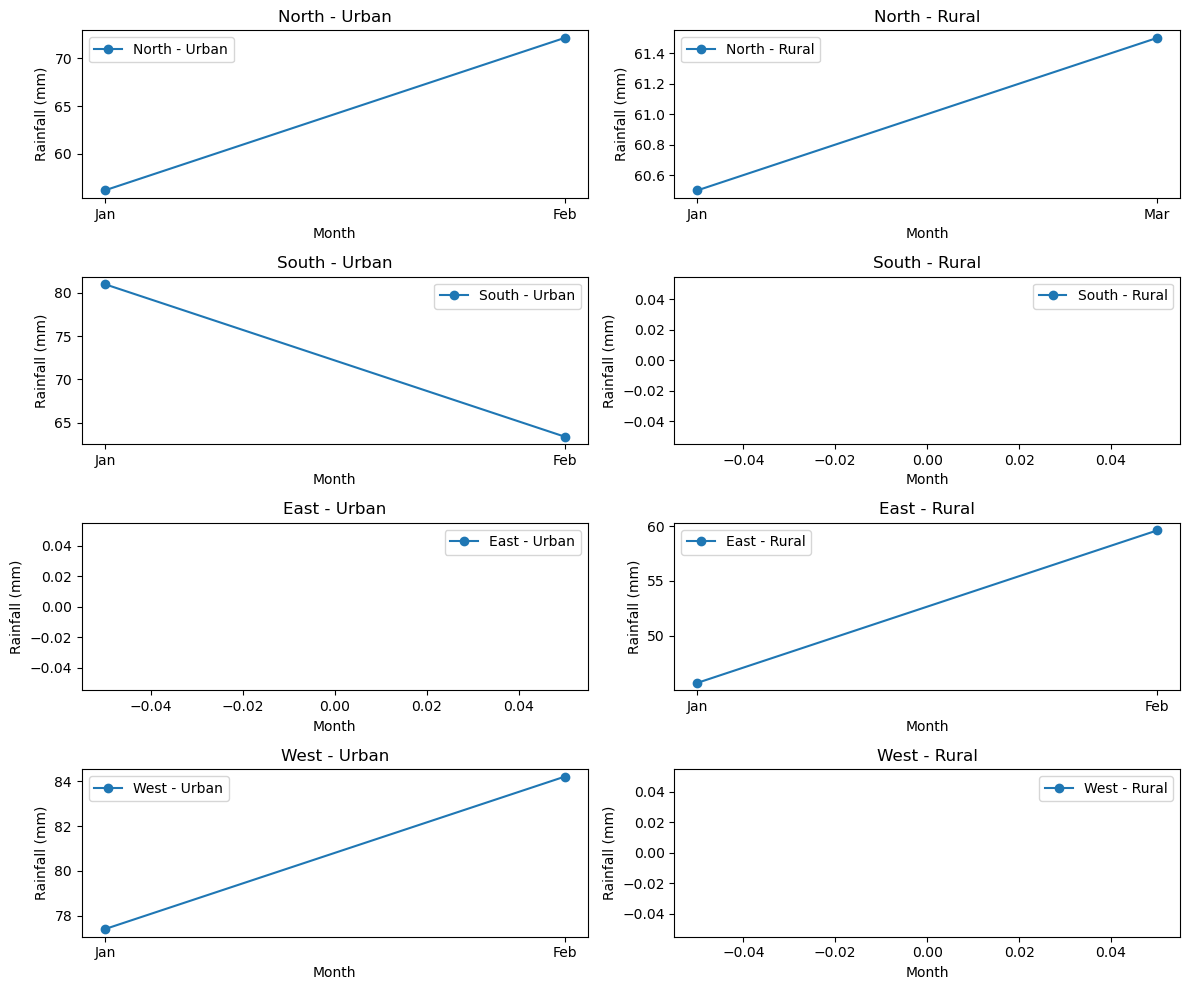

In [60]:
regions = df['Region'].unique()
urban_rural = df['UrbanRural'].unique()

nrows = len(regions)
ncols = len(urban_rural)

# Create facet/grid plot
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 10))

for i, region in enumerate(regions):
    for j, status in enumerate(urban_rural):
        ax = axes[i, j]  # Select the subplot
        filtered_data = df[(df['Region'] == region) & (df['UrbanRural'] == status)]
        
        # Plot the rainfall trend for this combination
        ax.plot(filtered_data['Month'], filtered_data['Rainfall_mm'], marker='o', label=f'{region} - {status}')
        
        # Add details
        ax.set_title(f'{region} - {status}')
        ax.set_xlabel('Month')
        ax.set_ylabel('Rainfall (mm)')
        ax.legend()

plt.tight_layout()
plt.savefig('facet_grid_rainfall_trends.png')
plt.show()


3. Write a brief summary (in a Markdown cell) of your main insights from the data and visualizations. (5 Marks)


#Write your summary here
### Summary of Insights

- The **rainfall patterns** vary significantly across different **regions** and between **urban and rural** areas.
- From the **facet grid plots**, we observe that **rural areas** tend to have slightly higher average rainfall in some regions, possibly due to less infrastructure and more open land.
- The **monthly trends** show that rainfall is **seasonal**, with some months (e.g., November, December) experiencing peaks in several regions.
- The **boxplots** highlight that certain regions have **outliers**, suggesting extreme weather conditions in specific areas or months.
- The **scatter plot** shows no strong relationship between maximum temperature and rainfall, indicating that high temperatures don't always mean high rainfall.
- Overall, the data suggests that **geographical location** and **urbanization** play a role in rainfall distribution, and monthly patterns should be considered in environmental or planning decisions.






